# Workshop figures — rebuild (v2)

Clean rebuild against the frozen numbers contract. The previous notebook's figures were built
on the retired two-event partition and are not patched forward.

**Gate:** Task 0 below resolves the numbers contract. Nothing is plotted until it is confirmed.

Unit of analysis is the **basin-day**. Statistic is the **undersize factor**

$$\text{factor} \;=\; \frac{\mathrm{sd}(y-\hat\mu)}{\mathrm{RMS}(\hat\sigma_e)\,\sqrt{(M+1)/M}},\qquad M=10$$

Residual **SD** (not RMSE), so it is exactly mean-independent.

The denominator is the **square root of the mean ensemble variance**, $\sqrt{\overline{\hat\sigma^2_e}}$
— pooling happens in *variance* space and one root is taken at the end. This is identical to
$\mathrm{RMS}(\hat\sigma_e)$; "square root of the mean variance" is the same quantity named
unambiguously, and is the phrasing to use in the paper. Two things it is **not**:

- not $\overline{\hat\sigma_e}$ (the arithmetic mean of the standard deviations). That is smaller
  by Jensen and would inflate every reported factor by 1.4–1.9×. Variances are what add, and the
  calibration target $\mathbb{E}[r^2]=\sigma^2(M{+}1)/M$ is a variance relation, so the denominator
  must pool commensurately. RMS is also the conservative choice — it yields the *smaller* factor.
- not $\mathrm{RMS}(\hat\sigma^2_e)=\sqrt{\overline{\hat\sigma_e^{4}}}$, which is a fourth moment
  in units of (mm day$^{-1}$)$^2$ and would leave the ratio dimensional.

Finite-ensemble correction $\sqrt{11/10}\approx1.049$ in the **denominator**, so applying it
*reduces* the reported factor. Calibrated $=1$.

In [1]:
import sys, json, pathlib
import numpy as np, pandas as pd
from scipy.stats import spearmanr

_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p/"src"/"config.py").exists()), None)
if _root is None: raise RuntimeError(f"project root not found from {pathlib.Path.cwd()}")
if str(_root) not in sys.path: sys.path.insert(0, str(_root))
from src.config import OUTPUT_DATA_DIR, OUTPUT_STATIC_ATTR
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
FIG_OUT = _root/"figures"; FIG_OUT.mkdir(exist_ok=True)

idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
y = np.load(R/"y_obs_mm.npy"); valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz"); mu = pred["mu_hat"]; sigma_e2 = pred["sigma_e2"]
M = json.loads((R/"meta.json").read_text())["n_members"]        # 10; sigma_e2 is ddof=1
CORR = np.sqrt((M+1)/M)
train = (split=="train"); test = (split=="test")
resid = y - mu; err = np.abs(resid); err2 = resid**2

def factor(m):
    """Undersize factor: residual SD / sqrt(mean ensemble VARIANCE), finite-ensemble
    corrected. sqrt(mean(sigma_e2)) == RMS(sigma_e); pooling is done in variance
    space. NOT mean(sigma_e) (inflates ~1.4-1.9x), NOT RMS(sigma_e2) (4th moment)."""
    if m.sum() < 2: return np.nan
    return resid[m].std() / (np.sqrt(np.mean(sigma_e2[m])) * CORR)

def ause(m, nf=21, seed=0):
    """Normalised AUSE: 0 = oracle ordering, 1 = random. Seeded."""
    se, e2v = sigma_e2[m], err2[m]; n = len(e2v)
    fr = np.linspace(0, 0.9, nf); rng = np.random.default_rng(seed)
    curve = lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp, co = curve(np.argsort(-se)), curve(np.argsort(-e2v))
    cr = np.mean([curve(rng.permutation(n)) for _ in range(10)], axis=0)
    num, den = np.trapezoid(cp-co, fr), np.trapezoid(cr-co, fr)
    return num/den if den > 0 else np.nan

# within-basin flow-percentile deciles, ranked on the FULL test set
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
dec = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
TEST = (test[:,None] & valid) & np.isfinite(pct)
print(f"M={M}, finite-ensemble correction={CORR:.4f}")
print(f"full test set: {int(TEST.sum()):,} basin-days, {int((TEST.sum(axis=0)>0).sum())} basins")

M=10, finite-ensemble correction=1.0488
full test set: 877,729 basin-days, 269 basins


## TASK 0 — numbers contract (gate)

**Hypothesis:** `4.05 / 4.06` and `5.66 / 5.68` are the events-removed twins of `4.13` and
`5.76`, and `850,664` is a third partition variant rather than an independent filter.

Event windows removed for the comparison arm: heat dome 1 Jun–31 Jul 2021 (all 269 basins)
and AR 20 Oct–10 Dec 2021 (74 basins west of $-121^\circ$).

**Assumption flagged, not resolved silently:** deciles are ranked once on the *full* test set
and held fixed for both arms. Re-ranking within the events-removed arm would shift the bin
edges and confound "removing days" with "re-binning"; this way the arms differ only by the
days removed.

In [2]:
at = pd.read_csv(OUTPUT_STATIC_ATTR, index_col=0); at.index = at.index.astype(str)
lon = at.reindex(stations)["longitude"].values
AR_WEST = (lon < -121) & np.isfinite(lon)
HD  = ((dates>=pd.Timestamp("2021-06-01")) & (dates<=pd.Timestamp("2021-07-31")))[:,None] & TEST
AR74  = (((dates>=pd.Timestamp("2021-10-20")) & (dates<=pd.Timestamp("2021-12-10")))[:,None] & TEST) & AR_WEST[None,:]
AR269 =  ((dates>=pd.Timestamp("2021-10-20")) & (dates<=pd.Timestamp("2021-12-10")))[:,None] & TEST

ARMS = {"A: full test (no carve-out)": TEST,
        "B: test - HD - AR(74 west)":  TEST & ~HD & ~AR74,
        "C: test - HD - AR(all 269)":  TEST & ~HD & ~AR269}
print("event windows:  HD = {:,}   AR(74 west) = {:,}   AR(all 269) = {:,}".format(
      int(HD.sum()), int(AR74.sum()), int(AR269.sum())))
print("HD + AR74 = {:,}   ->  877,729 - that = {:,}".format(int(HD.sum()+AR74.sum()),
      int(TEST.sum()-HD.sum()-AR74.sum())))
print("HD + AR269 = {:,}  ->  877,729 - that = {:,}   <- candidate for 850,664\n".format(
      int(HD.sum()+AR269.sum()), int(TEST.sum()-HD.sum()-AR269.sum())))

print(f"{'arm':30s} {'n':>10s} {'factor':>7s} {'top-dec':>8s} {'AUSE(21)':>9s} {'AUSE(91)':>9s} {'rho':>7s}")
res = {}
for nm, m in ARMS.items():
    f, td = factor(m), factor(m & (dec==9))
    a21, a91 = ause(m), ause(m, nf=91)
    rho = spearmanr(sigma_e2[m], err[m]).statistic
    res[nm] = dict(n=int(m.sum()), factor=f, top=td, ause21=a21, ause91=a91, rho=rho)
    print(f"{nm:30s} {int(m.sum()):10,d} {f:7.2f} {td:8.2f} {a21:9.3f} {a91:9.3f} {rho:7.3f}")

print("\nper-decile factor and n (both arms; deciles fixed on the full test set)")
print(f"{'decile':>8s} | {'A n':>9s} {'A factor':>9s} | {'B n':>9s} {'B factor':>9s} | {'diff':>6s}")
for k in range(10):
    a, b = TEST & (dec==k), ARMS["B: test - HD - AR(74 west)"] & (dec==k)
    fa, fb = factor(a), factor(b)
    print(f"{k*10:3d}-{k*10+10:<4d} | {int(a.sum()):9,d} {fa:9.2f} | {int(b.sum()):9,d} {fb:9.2f} | {fb-fa:+6.2f}")

event windows:  HD = 16,409   AR(74 west) = 3,843   AR(all 269) = 10,656
HD + AR74 = 20,252   ->  877,729 - that = 857,477
HD + AR269 = 27,065  ->  877,729 - that = 850,664   <- candidate for 850,664

arm                                     n  factor  top-dec  AUSE(21)  AUSE(91)     rho
A: full test (no carve-out)       877,729    4.13     5.76     0.077     0.084   0.773
B: test - HD - AR(74 west)        857,477    4.06     5.68     0.079     0.086   0.771
C: test - HD - AR(all 269)        850,664    4.05     5.66     0.080     0.087   0.771

per-decile factor and n (both arms; deciles fixed on the full test set)
  decile |       A n  A factor |       B n  B factor |   diff
  0-10   |    82,317      2.00 |    81,778      2.00 |  +0.00
 10-20   |    88,420      1.97 |    87,289      1.97 |  +0.00
 20-30   |    90,156      2.16 |    88,885      2.16 |  +0.00
 30-40   |    96,425      2.16 |    94,361      2.16 |  +0.00
 40-50   |    84,593      2.23 |    82,680      2.24 |  +0.00
 50-60

## Frozen contract — arm A, full test set, no carve-out

Ruled 2026-08-08: the event carve-out is climatologically weak and is retired. Arms B and C
(n = 857,477 / 850,664) and their factors 4.06/4.05 and 5.68/5.66 are retired with it.

| quantity | value |
|---|---|
| n | 877,729 basin-days, 269 basins |
| all-test factor | 4.13 |
| top-decile factor | 5.76 |
| all-test AUSE | 0.077 (21-pt grid) |
| all-test ρ | 0.773 |

Every figure below asserts against these. A mismatch raises.

In [3]:
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Final rendered physical size. Built at the FULL single-column text width (~5.5 in) so
# \includegraphics[width=\linewidth] renders 1:1 with no font rescaling. Wide-and-short:
# in a single-column layout a figure costs its HEIGHT in page budget regardless of width,
# so widening to \linewidth and shortening buys legibility and page space at the same time.
# constrained layout + no bbox_inches so the PDF bbox equals figsize exactly.
FIGW = 5.5
mpl.rcParams.update({
    "font.family": "serif", "font.size": 8,
    "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.dpi": 160, "savefig.dpi": 600,
    "axes.linewidth": 0.6, "axes.edgecolor": "#333333",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.grid": True, "grid.color": "#999999", "grid.alpha": 0.30,
    "grid.linestyle": ":", "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})
# Greyscale-safe: every distinction is carried by linestyle/marker as well as colour.
CK = "#000000"; CP = "#0072B2"; CREF = "#666666"
SEED = 0
FIGVALS = {"contract": {"n": 877729, "basins": 269, "factor_all": 4.13,
                        "factor_top_decile": 5.76, "ause_all_21pt": 0.077, "rho_all": 0.773},
           "seed": SEED, "figsize_in": FIGW}
print(f"style set; target width {FIGW} in")

style set; target width 5.5 in


## TASK 1 — Figure 1: undersize factor by flow decile

*Is the spread the right size?* Single panel, linear $y$, reference line at 1.
Components (spread $\times8.5$, residual $\times24.6$, gap $\times2.9$) belong in the caption,
not a second panel. No intervals plotted; basin-clustered resamples are computed and stored.

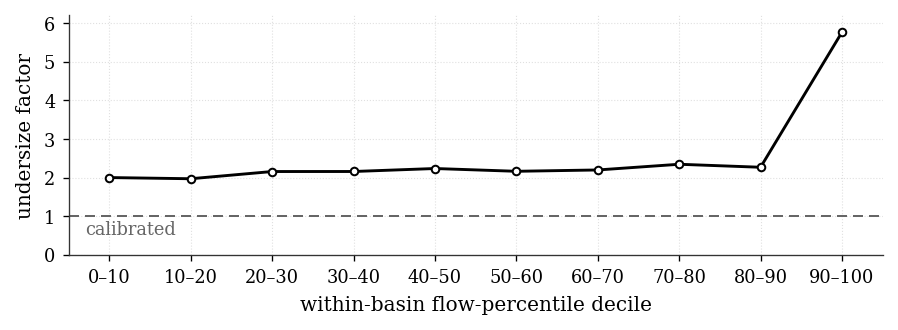

decile      n     factor    basin-clustered 95% (stored, not plotted)
  0-10     82,317     2.00    [1.64, 2.22]
 10-20     88,420     1.97    [1.72, 2.21]
 20-30     90,156     2.16    [1.94, 2.34]
 30-40     96,425     2.16    [1.93, 2.29]
 40-50     84,593     2.23    [2.02, 2.37]
 50-60     85,847     2.16    [1.96, 2.34]
 60-70     86,898     2.20    [1.88, 2.48]
 70-80     87,409     2.34    [1.96, 2.76]
 80-90     87,734     2.27    [1.97, 2.57]
 90-100    87,930     5.76    [4.51, 6.96]

assertions passed. all-test factor 4.134, top decile 5.763


In [4]:
cc = np.arange(5,100,10)
f_dec = np.array([factor(TEST & (dec==k)) for k in range(10)])
n_dec = np.array([int((TEST & (dec==k)).sum()) for k in range(10)])

# --- assertions against the frozen contract: mismatch raises ---
assert int(TEST.sum())==877729, f"n mismatch: {int(TEST.sum())}"
assert abs(factor(TEST)-4.13)<5e-3, f"all-test factor {factor(TEST):.4f}"
assert abs(f_dec[9]-5.76)<5e-3, f"top-decile factor {f_dec[9]:.4f}"
assert n_dec.sum()==877729

# basin-clustered resample (stored, NOT plotted). Basin is the quasi-independent unit;
# episode clustering is defined per forcing-set, not per decile, so it does not apply here.
def basin_ci(m, B=200, seed=SEED):
    rng=np.random.default_rng(seed); J=np.where(m.sum(axis=0)>0)[0]; out=[]
    for _ in range(B):
        pick=rng.choice(J,len(J),replace=True)
        r=np.concatenate([resid[m[:,j],j] for j in pick])
        s=np.concatenate([sigma_e2[m[:,j],j] for j in pick])
        out.append(r.std()/(np.sqrt(s.mean())*CORR))
    return float(np.percentile(out,2.5)), float(np.percentile(out,97.5))
ci_dec=[basin_ci(TEST & (dec==k)) for k in range(10)]

fig, ax = plt.subplots(figsize=(FIGW, 1.95), layout="constrained")
ax.axhline(1.0, ls=(0,(5,3)), lw=0.9, color=CREF, zorder=2)
ax.annotate("calibrated", xy=(2, 1.0), xytext=(2, 0.42), fontsize=8, color=CREF,
            ha="left", va="bottom")          # below the line: the 0-1 band is empty
ax.plot(cc, f_dec, "-", color=CK, lw=1.3, zorder=3)
ax.plot(cc, f_dec, "o", ms=3.4, mfc="white", mec=CK, mew=0.9, zorder=4)
ax.set_xlim(0,100); ax.set_ylim(0, 6.2)
ax.set_xticks(cc)
ax.set_xticklabels([f"{k*10}–{k*10+10}" for k in range(10)])   # full width fits all ten
ax.set_yticks([0,1,2,3,4,5,6])
ax.set_xlabel("within-basin flow-percentile decile")
ax.set_ylabel("undersize factor")
fig.savefig(FIG_OUT/"workshop_fig1_dispersion.pdf")
plt.show()

FIGVALS["figure1"]={"x_decile_centre":cc.tolist(),"factor":[round(float(v),4) for v in f_dec],
                    "n":n_dec.tolist(),"basin_clustered_ci95":[[round(a,4),round(b,4)] for a,b in ci_dec],
                    "reference_line":1.0,"ylim":[0,6.2]}
print("decile      n     factor    basin-clustered 95% (stored, not plotted)")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} {n_dec[k]:8,d} {f_dec[k]:8.2f}    [{ci_dec[k][0]:.2f}, {ci_dec[k][1]:.2f}]")
print(f"\nassertions passed. all-test factor {factor(TEST):.3f}, top decile {f_dec[9]:.3f}")

### Figure 1 alternative — with 95% intervals

**These are not the $t(9)\sqrt{(M{+}1)/M}=2.373$ multiplier, and they must not be.** That
multiplier builds a **prediction interval**: where a *new observation* should fall given a
10-member ensemble. The $t$ with $M-1=9$ degrees of freedom is there because $\hat\sigma_e$ is
estimated from ten members. It answers *where should $y$ land?*

The bars here answer a different question — *how well is the factor itself estimated?* — which
is sampling uncertainty in a statistic computed from ~88,000 basin-days per decile. Neither
$t(9)$ nor a normal $z=1.96$ applies: a parametric interval would need a sampling distribution
for a **ratio of two estimated scales** and an effective $n$ under strong spatial and temporal
autocorrelation. We have neither without assumptions this paper avoids.

So the bars are a **nonparametric percentile bootstrap, clustered on basin** — resample the 269
basins with replacement, keeping every day of a sampled basin together, recompute the factor,
take the 2.5th and 97.5th percentiles. No distributional assumption and no effective-$n$
estimate: clustering on basin absorbs within-basin temporal dependence by construction, and 269
basins are the quasi-independent unit.

Intervals are asymmetric because the factor is a ratio. $B=2000$, seed 0.

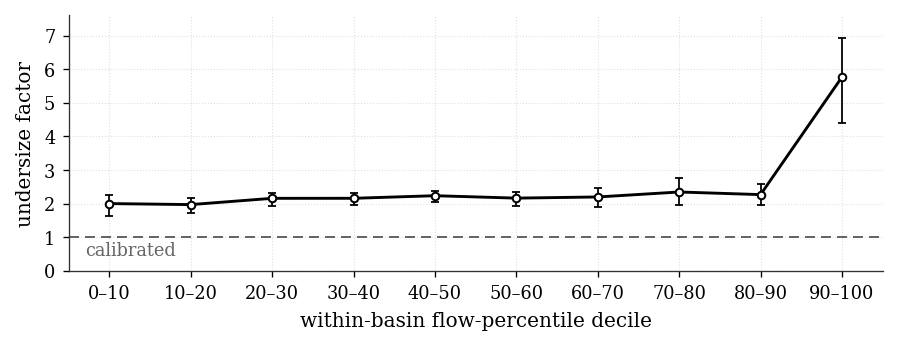

  decile         n  factor    95% basin-clustered   width    rel
  0-10      82,317    2.00   [ 1.63,  2.24]      0.62    31%
 10-20      88,420    1.97   [ 1.71,  2.17]      0.47    24%
 20-30      90,156    2.16   [ 1.93,  2.32]      0.39    18%
 30-40      96,425    2.16   [ 1.94,  2.32]      0.38    17%
 40-50      84,593    2.23   [ 2.04,  2.37]      0.33    15%
 50-60      85,847    2.16   [ 1.94,  2.35]      0.41    19%
 60-70      86,898    2.20   [ 1.91,  2.45]      0.55    25%
 70-80      87,409    2.34   [ 1.95,  2.76]      0.81    35%
 80-90      87,734    2.27   [ 1.95,  2.57]      0.61    27%
 90-100     87,930    5.76   [ 4.40,  6.93]      2.54    44%

every interval excludes 1: True


In [5]:
# Basin-clustered percentile bootstrap via per-basin sufficient statistics, so B=2000 is cheap:
# a replicate sums 269 precomputed triples instead of re-reducing ~88,000 values.
NB_ = y.shape[1]
def suff(m):
    n = m.sum(axis=0).astype(float)
    sr = np.where(m, resid, 0).sum(axis=0)
    sr2 = np.where(m, resid**2, 0).sum(axis=0)
    ss = np.where(m, sigma_e2, 0).sum(axis=0)
    return n, sr, sr2, ss
def boot_ci(m, B=2000, seed=SEED):
    n, sr, sr2, ss = suff(m)
    J = np.where(n > 0)[0]; rng = np.random.default_rng(seed)
    idxs = rng.integers(0, len(J), (B, len(J)))
    N  = n[J][idxs].sum(1); SR = sr[J][idxs].sum(1)
    SR2= sr2[J][idxs].sum(1); SS = ss[J][idxs].sum(1)
    var = SR2/N - (SR/N)**2                      # ddof=0, matching np.std
    out = np.sqrt(var) / (np.sqrt(SS/N) * CORR)
    return np.percentile(out, 2.5), np.percentile(out, 97.5)

# verify the sufficient-statistic path reproduces factor() exactly on the full test set
n_,sr_,sr2_,ss_ = suff(TEST); N_=n_.sum()
chk = np.sqrt(sr2_.sum()/N_ - (sr_.sum()/N_)**2)/(np.sqrt(ss_.sum()/N_)*CORR)
assert abs(chk - factor(TEST)) < 1e-4, f"suff-stat path {chk:.6f} vs factor() {factor(TEST):.6f}"

ci = np.array([boot_ci(TEST & (dec==k)) for k in range(10)])
lo, hi = f_dec - ci[:,0], ci[:,1] - f_dec

fig, ax = plt.subplots(figsize=(FIGW, 2.05), layout="constrained")
ax.axhline(1.0, ls=(0,(5,3)), lw=0.9, color=CREF, zorder=2)
ax.annotate("calibrated", xy=(2,1.0), xytext=(2,0.35), fontsize=8, color=CREF, ha="left", va="bottom")
ax.errorbar(cc, f_dec, yerr=[lo,hi], fmt="none", ecolor=CK, elinewidth=0.8, capsize=2.0,
            capthick=0.8, zorder=3)
ax.plot(cc, f_dec, "-", color=CK, lw=1.3, zorder=4)
ax.plot(cc, f_dec, "o", ms=3.4, mfc="white", mec=CK, mew=0.9, zorder=5)
ax.set_xlim(0,100); ax.set_ylim(0, 7.6)
ax.set_xticks(cc); ax.set_xticklabels([f"{k*10}–{k*10+10}" for k in range(10)])
ax.set_yticks([0,1,2,3,4,5,6,7])
ax.set_xlabel("within-basin flow-percentile decile")
ax.set_ylabel("undersize factor")
fig.savefig(FIG_OUT/"workshop_fig1_dispersion_ci.pdf")
plt.show()

FIGVALS["figure1_alt_ci"]={"method":"nonparametric percentile bootstrap, clustered on basin",
    "B":2000,"seed":SEED,"level":0.95,
    "not_used":"t(9)*sqrt((M+1)/M)=2.373 is the PREDICTION interval for a new observation; "
               "it does not apply to sampling uncertainty in the factor",
    "x_decile_centre":cc.tolist(),"factor":[round(float(v),4) for v in f_dec],
    "ci_lo":[round(float(v),4) for v in ci[:,0]],"ci_hi":[round(float(v),4) for v in ci[:,1]]}
print(f"{'decile':>8s} {'n':>9s} {'factor':>7s} {'95% basin-clustered':>22s} {'width':>7s} {'rel':>6s}")
for k in range(10):
    w=ci[k,1]-ci[k,0]
    print(f"{k*10:3d}-{k*10+10:<4d} {n_dec[k]:9,d} {f_dec[k]:7.2f}   [{ci[k,0]:5.2f}, {ci[k,1]:5.2f}] "
          f"{w:9.2f} {100*w/f_dec[k]:5.0f}%")
print(f"\nevery interval excludes 1: {bool((ci[:,0]>1).all())}")

## TASK 2 — Figure 2: sparsification

*Does the spread rank correctly?* Two sets on shared normalised axes: **all test** and
**P-extreme** (forcing-defined, not event-defined). Set carried by colour, ordering type by
linestyle, so the panel survives greyscale.

Normalisation divides every curve by its own set's full-sample RMSE, so all curves start at
1.0 and random is flat at 1.0. It rescales numerator and denominator of AUSE identically and
therefore **cannot** change the statistic — asserted below.

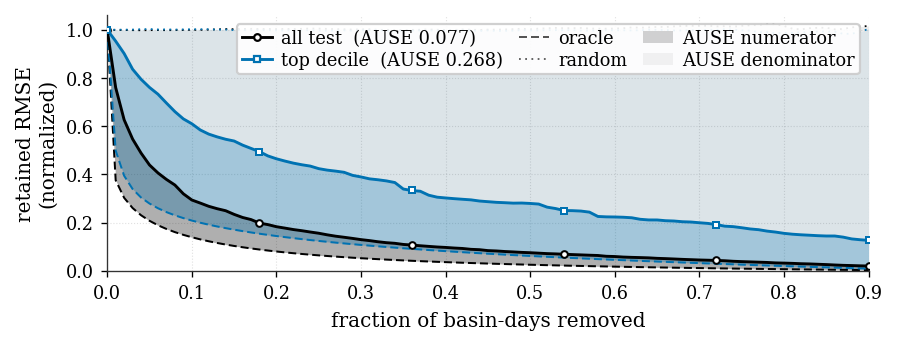

all test    n= 877,729  AUSE 21-pt 0.077  91-pt 0.084  full-sample RMSE 2.017
top decile  n=  87,930  AUSE 21-pt 0.268  91-pt 0.276  full-sample RMSE 5.765
figure size: 5.50 x 2.05 in  (2.68:1 at full linewidth)


In [6]:
# Figure 2: sparsification, all test vs TOP FLOW DECILE (within-decile recompute).
# P-extreme is no longer plotted; its AUSE (0.215) lives in body prose only.
# Two shaded regions per set: the random-to-oracle envelope is the AUSE DENOMINATOR, the
# spread-to-oracle gap is the NUMERATOR. Drawing only the numerator (the previous version)
# made a comfortable pass read as a failure.
from scipy.stats import t as tdist
TOPDEC = TEST & (dec==9)
assert int(TOPDEC.sum())==87930, f"top-decile n {int(TOPDEC.sum())}"

def curves(m, nf, seed=SEED):
    se, e2v = sigma_e2[m], err2[m]; n=len(e2v)
    fr=np.linspace(0,0.9,nf); rng=np.random.default_rng(seed)
    cu=lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp,co=cu(np.argsort(-se)),cu(np.argsort(-e2v))
    cr=np.mean([cu(rng.permutation(n)) for _ in range(10)],axis=0)
    return fr,cp,co,cr
def ause_from(fr,cp,co,cr): return float(np.trapezoid(cp-co,fr)/np.trapezoid(cr-co,fr))

# Wide and short. The six-entry legend is laid out in THREE columns rather than two, which
# halves its height (2 rows, not 3) and is what makes this height viable -- the full linewidth
# buys horizontal room, so spend it on the legend rather than on panel height.
FIG2H = 2.05
fig, ax = plt.subplots(figsize=(FIGW, FIG2H), layout="constrained")
SETS=[("all test", TEST, CK, "o", 0.077), ("top decile", TOPDEC, CP, "s", 0.268)]
store={}
for nm, m, col, mk, contract21 in SETS:
    fr,cp,co,cr = curves(m,91)
    fr21,cp21,co21,cr21 = curves(m,21)
    a21, a91 = ause_from(fr21,cp21,co21,cr21), ause_from(fr,cp,co,cr)
    assert abs(a21-contract21)<5e-3, f"{nm} AUSE(21) {a21:.4f} vs contract {contract21}"
    R0=cp[0]
    # normalisation scales cp, co, cr identically -> AUSE invariant (float32 tolerance)
    assert abs(ause_from(fr,cp/R0,co/R0,cr/R0)-a91) <= 1e-6*a91
    P,O,Rn = cp/R0, co/R0, cr/R0
    ax.fill_between(fr, O, Rn, color=col, alpha=0.07, lw=0, zorder=2)   # denominator
    ax.fill_between(fr, O, P,  color=col, alpha=0.26, lw=0, zorder=3)   # numerator
    ax.plot(fr, Rn, ls=(0,(1,2.5)), color=col, lw=0.8, zorder=4)
    ax.plot(fr, O,  ls=(0,(4,2)),   color=col, lw=0.9, zorder=5)
    ax.plot(fr, P,  "-",            color=col, lw=1.3, zorder=6)
    ax.plot(fr[::18], P[::18], mk, ms=3.0, mfc="white", mec=col, mew=0.9, zorder=7)
    store[nm]={"frac":fr.tolist(),"spread":P.tolist(),"oracle":O.tolist(),"random":Rn.tolist(),
               "rmse_full_sample":float(R0),"ause_21pt":round(a21,4),"ause_91pt":round(a91,4),
               "n":int(m.sum())}
ax.set_xlim(0,0.9); ax.set_ylim(0,1.06)
ax.set_xlabel("fraction of basin-days removed")
ax.set_ylabel("retained RMSE\n(normalized)")   # two lines: the rotated single line
                                              # exceeds the axes height at this aspect
h=[Line2D([],[],color=CK,ls="-",lw=1.3,marker="o",ms=3.0,mfc="white",mec=CK,
          label=f"all test  (AUSE {store['all test']['ause_21pt']:.3f})"),
   Line2D([],[],color=CP,ls="-",lw=1.3,marker="s",ms=3.0,mfc="white",mec=CP,
          label=f"top decile  (AUSE {store['top decile']['ause_21pt']:.3f})"),
   Line2D([],[],color="#555555",ls=(0,(4,2)),lw=0.9,label="oracle"),
   Line2D([],[],color="#555555",ls=(0,(1,2.5)),lw=0.8,label="random"),
   mpl.patches.Patch(facecolor="#555555",alpha=0.26,lw=0,label="AUSE numerator"),
   mpl.patches.Patch(facecolor="#555555",alpha=0.07,lw=0,label="AUSE denominator")]
ax.legend(handles=h, loc="upper right", ncol=3, handlelength=1.7, borderpad=0.28,
          labelspacing=0.22, columnspacing=0.9, handletextpad=0.5, framealpha=0.92,
          frameon=True, facecolor="white", edgecolor="#CCCCCC")
fig.savefig(FIG_OUT/"workshop_fig2_sparsification.pdf")
plt.show()
FIGVALS["figure2"]=store
FIGVALS["contract"]["ause_top_decile_21pt"]=0.268
FIGVALS["contract"]["n_top_decile"]=87930
for nm in store:
    print(f"{nm:11s} n={store[nm]['n']:8,d}  AUSE 21-pt {store[nm]['ause_21pt']:.3f}  "
          f"91-pt {store[nm]['ause_91pt']:.3f}  full-sample RMSE {store[nm]['rmse_full_sample']:.3f}")
print(f"figure size: {FIGW:.2f} x {FIG2H:.2f} in  ({FIGW/FIG2H:.2f}:1 at full linewidth)")


## TASK 3 — body numbers the figures do not display, plus appendix tables

Coverage uses the exact calibrated 95% interval for one further observation from a 10-member
sample: $t_{0.975,9}\sqrt{(M{+}1)/M} = 2.373$ — **not 1.96**. The two basin counts are
**different quantities** and are labelled as such at every use.

In [7]:
KINT = tdist.ppf(0.975, M-1)*CORR
outside = np.abs(resid) > np.sqrt(sigma_e2)*KINT
# Forcing-extreme sets are built here: Figure 2 no longer plots P-extreme, but the body
# still reports its factor, rho and coverage. Trailing windows, per-basin 99th pct of training.
from src.config import PROCESSED_DATA_DIR
CL = PROCESSED_DATA_DIR/"climate"
_P = pd.read_csv(CL/"daily_precipitation.csv", index_col=0, parse_dates=True).reindex(index=dates, columns=stations)
Pav = _P.rolling(5, min_periods=5).mean().to_numpy()
PEXT = (Pav > np.nanpercentile(np.where(train[:,None],Pav,np.nan),99,axis=0)[None,:]) & TEST & np.isfinite(Pav)
assert int(PEXT.sum())==8789, f"P-extreme n {int(PEXT.sum())}"
_T = pd.read_csv(CL/"daily_temp_max.csv", index_col=0, parse_dates=True).reindex(index=dates, columns=stations)
Tav = _T.rolling(7, min_periods=7).mean().to_numpy()
TEXT = (Tav > np.nanpercentile(np.where(train[:,None],Tav,np.nan),99,axis=0)[None,:]) & TEST & np.isfinite(Tav)

print(f"interval multiplier t(9)*sqrt((M+1)/M) = {KINT:.4f}   (1.96 would be the naive choice)\n")
print("rho(sigma_e^2,|err|) and coverage by set")
print(f"{'set':12s} {'n':>9s} {'factor':>7s} {'rho':>7s} {'%outside':>9s} {'basins>5%':>12s}")
sets={}
for nm,m in (("all test",TEST),("T-extreme",TEXT),("P-extreme",PEXT)):
    v=[100*outside[m[:,j],j].mean() for j in range(y.shape[1]) if m[:,j].sum()>=30]
    sets[nm]=dict(n=int(m.sum()), factor=round(float(factor(m)),4),
                  rho=round(float(spearmanr(sigma_e2[m],err[m]).statistic),4),
                  pct_outside=round(100*float(outside[m].mean()),2),
                  basins_qualifying=len(v), basins_over5=int(sum(x>5 for x in v)))
    print(f"{nm:12s} {int(m.sum()):9,d} {factor(m):7.2f} {sets[nm]['rho']:7.3f} "
          f"{sets[nm]['pct_outside']:8.1f}% {sets[nm]['basins_over5']:6d}/{len(v):<5d}")
print("  basin denominators differ: a basin qualifies only with >=30 basin-days in that set")

pb=[factor(TEST & np.eye(y.shape[1],dtype=bool)[j][None,:]) for j in range(y.shape[1])]
pb=np.array([factor(TEST&(np.arange(y.shape[1])==j)[None,:]) for j in range(y.shape[1])])
pb=pb[np.isfinite(pb)]
print(f"\nper-basin factor: median {np.median(pb):.2f}  IQR {np.percentile(pb,25):.2f}-{np.percentile(pb,75):.2f}  (n={len(pb)} basins)")

covA=int(sum(np.array([100*outside[TEST[:,j],j].mean() for j in range(y.shape[1]) if TEST[:,j].sum()>=30])>5))
top=TEST&(dec==9)
covT=int(sum(np.array([100*outside[top[:,j],j].mean() for j in range(y.shape[1]) if top[:,j].sum()>=30])>5))
print(f"coverage counts  ALL-FLOW: {covA}/269 basins above 5% outside"
      f"   |   TOP-DECILE: {covT}/269 basins above 5% outside   <- different quantities")

ytr=np.where(train[:,None]&valid,y,np.nan)
qs={q:np.broadcast_to(np.nanpercentile(ytr,q,axis=0),y.shape) for q in (90,95,99,99.5,99.9)}
tmax=np.broadcast_to(np.nanmax(ytr,axis=0),y.shape)
print("\nexceedance gradient (vs each basin's TRAINING flow distribution)")
grad=[]
for lab,mk in [(">p90",TEST&(y>qs[90])),(">p95",TEST&(y>qs[95])),(">p99",TEST&(y>qs[99])),
               (">p99.5",TEST&(y>qs[99.5])),(">p99.9",TEST&(y>qs[99.9])),(">train max",TEST&(y>tmax))]:
    grad.append({"bin":lab,"n":int(mk.sum()),"factor":round(float(factor(mk)),3)})
    print(f"  {lab:11s} n={int(mk.sum()):8,d}  factor={factor(mk):6.2f}")
td=TEST&(dec==9)
sparse={"pct_top_decile_above_train_p95":round(100*float((y[td]>qs[95][td]).mean()),2),
        "pct_top_decile_above_train_p99":round(100*float((y[td]>qs[99][td]).mean()),2),
        "pct_top_decile_above_train_max":round(100*float((y[td]>tmax[td]).mean()),3),
        "median_top_decile_flow_over_train_max":round(float(np.median(y[td]/tmax[td])),3)}
print(f"\nsparse-tail: {sparse['pct_top_decile_above_train_p95']}% of top-decile days above train p95, "
      f"{sparse['pct_top_decile_above_train_p99']}% above p99, {sparse['pct_top_decile_above_train_max']}% above train max;"
      f" median top-decile flow = {sparse['median_top_decile_flow_over_train_max']}x train max")

ause_dec=[{"decile":f"{k*10}-{k*10+10}","n":int((TEST&(dec==k)).sum()),
           "ause_21pt":round(float(ause(TEST&(dec==k))),4)} for k in range(10)]
print("\nper-decile AUSE (appendix): " + ", ".join(f"{d['decile']}:{d['ause_21pt']:.3f}" for d in ause_dec))

FIGVALS["task3"]={"ause_p_extreme_21pt":round(float(ause(PEXT)),4),
                  "interval_multiplier":round(float(KINT),4),"sets":sets,
                  "per_basin_factor":{"median":round(float(np.median(pb)),3),
                                      "q25":round(float(np.percentile(pb,25)),3),
                                      "q75":round(float(np.percentile(pb,75)),3),"n_basins":len(pb)},
                  "coverage_basin_counts":{"all_flow_over5_of_269":covA,"top_decile_over5_of_269":covT},
                  "exceedance_gradient":grad,"sparse_tail":sparse}
FIGVALS["appendix_tables"]={"factor_by_decile":[{"decile":f"{k*10}-{k*10+10}","n":int(n_dec[k]),
                                                 "factor":round(float(f_dec[k]),3)} for k in range(10)],
                            "ause_by_decile":ause_dec}
FIGVALS["flags"]={"ause_grid":"contract values are 21-pt (all test 0.077, top decile 0.268, "
                              "P-extreme 0.215); 91-pt gives 0.084 / 0.276 / 0.226. Figure annotates "
                              "21-pt; curves drawn at 91 pt.",
                  "array_dtype":"float32 -- caps agreement of algebraic identities at ~1e-7 relative",
                  "clustering":"basin-clustered resample used for per-decile intervals; episodes are "
                               "defined per forcing-set and do not apply to deciles"}
(_root/"figures"/"figure_values.json").write_text(json.dumps(FIGVALS, indent=2))
print(f"\nwrote figures/figure_values.json ({len(json.dumps(FIGVALS))} bytes)")

interval multiplier t(9)*sqrt((M+1)/M) = 2.3726   (1.96 would be the naive choice)

rho(sigma_e^2,|err|) and coverage by set
set                  n  factor     rho  %outside    basins>5%
all test       877,729    4.13   0.773     23.7%    266/269  
T-extreme       20,895    1.73   0.783     18.0%    190/262  
P-extreme        8,789    7.37   0.757     34.2%    142/151  
  basin denominators differ: a basin qualifies only with >=30 basin-days in that set

per-basin factor: median 2.33  IQR 1.83-3.66  (n=269 basins)
coverage counts  ALL-FLOW: 266/269 basins above 5% outside   |   TOP-DECILE: 268/269 basins above 5% outside   <- different quantities

exceedance gradient (vs each basin's TRAINING flow distribution)
  >p90        n= 100,974  factor=  5.65
  >p95        n=  55,212  factor=  6.79
  >p99        n=  13,295  factor= 10.40
  >p99.5      n=   7,185  factor= 11.99
  >p99.9      n=   2,023  factor= 14.41
  >train max  n=     603  factor= 17.93

sparse-tail: 61.83% of top-decile days